# Comparações Não e Sim

In [1]:
from analise_sinal import analiseEspectral

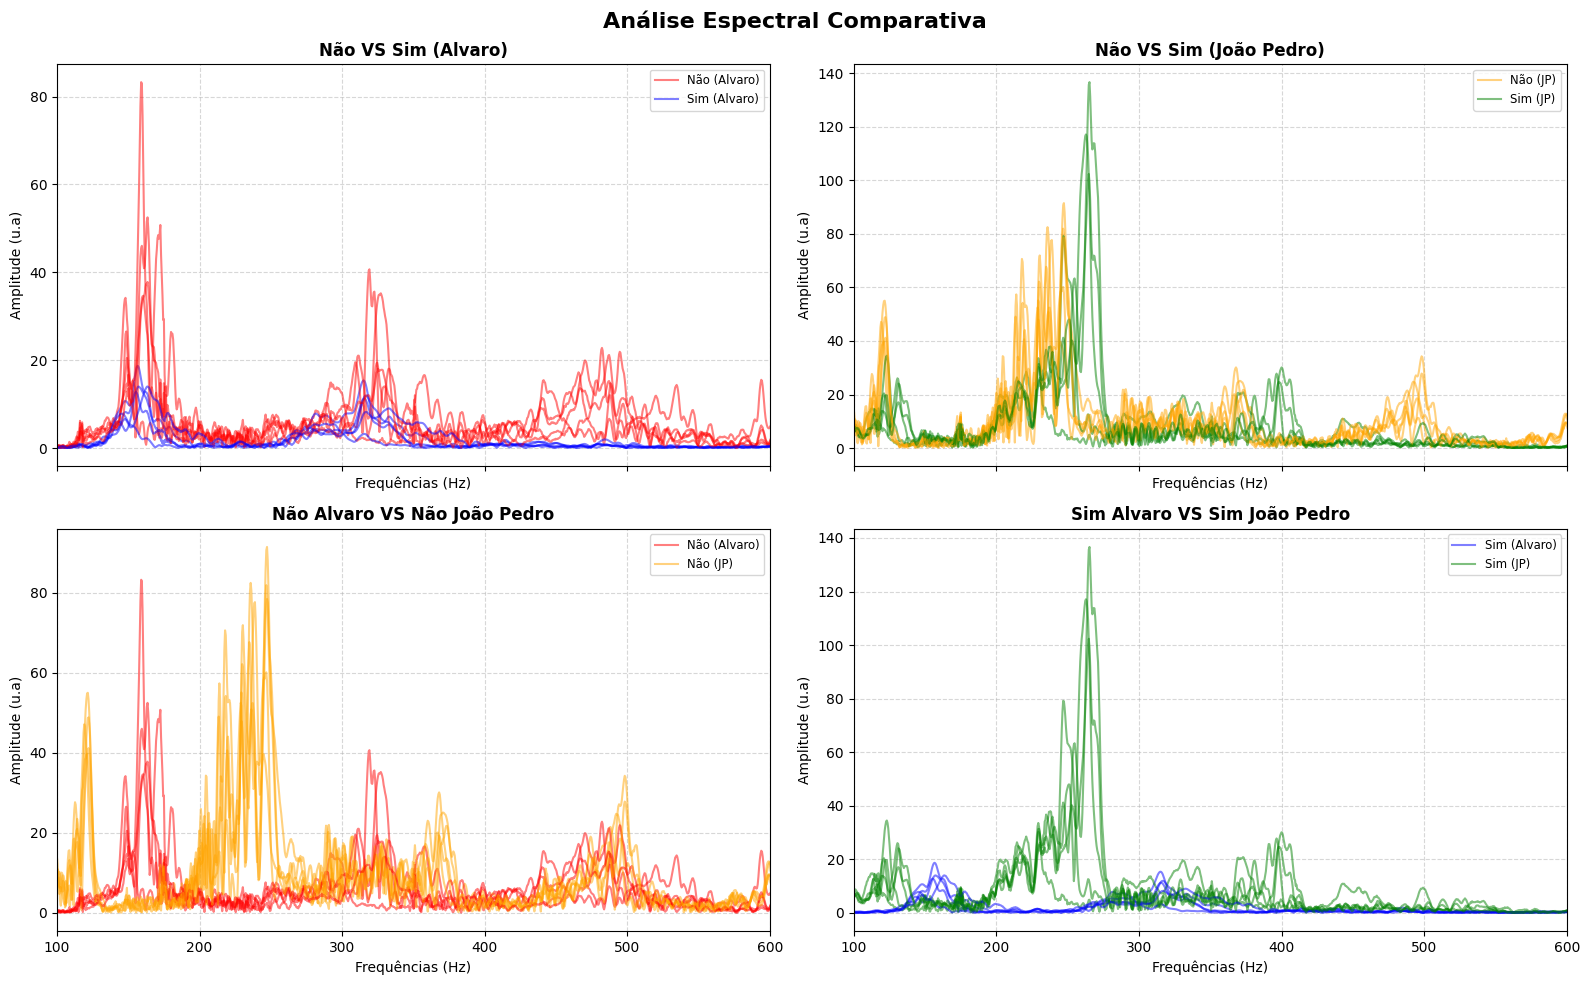

In [ ]:
import matplotlib.pyplot as plt

# Parâmetros
diretorioArquivo = "audios_cortados"
frequenciadeCorte = 600
amostras = 10

todos_picos_nao_alv = []
todos_picos_sim_alv = []
todos_picos_nao_jp = []
todos_picos_sim_jp = []


fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for i in range(1, 6):
    try:
        
        nome_nao = f"nao_alv_{i}.m4a"
        f_n, amp_n = analiseEspectral.analiseporFourier(diretorioArquivo, nome_nao)
        peaksFrequencias_naoAlvaro, peaksAmplitudes_naoAlvaro = analiseEspectral.selecionarPeaks(f_n, amp_n, frequenciadeCorte, amostras)
        todos_picos_nao_alv.append((peaksFrequencias_naoAlvaro, peaksAmplitudes_naoAlvaro))
        
        nome_sim = f"sim_alv_{i}.m4a"
        f_s, amp_s = analiseEspectral.analiseporFourier(diretorioArquivo, nome_sim)
        peaksFrequencias_simAlvaro, peaksAmplitudes_simAlvaro = analiseEspectral.selecionarPeaks(f_s, amp_s, frequenciadeCorte, amostras)
        todos_picos_sim_alv.append((peaksFrequencias_simAlvaro, peaksAmplitudes_simAlvaro))

        
        jp_nao = f"nao_jp_{i}.m4a"
        f_n_jp, amp_n_jp = analiseEspectral.analiseporFourier(diretorioArquivo, jp_nao)
        peaksFrequencias_naoJP, peaksAmplitudes_naoJP = analiseEspectral.selecionarPeaks(f_n_jp, amp_n_jp, frequenciadeCorte, amostras)
        todos_picos_nao_jp.append((peaksFrequencias_naoJP, peaksAmplitudes_naoJP))

        jp_sim = f"sim_jp_{i}.m4a"
        f_s_jp, amp_s_jp = analiseEspectral.analiseporFourier(diretorioArquivo, jp_sim)
        peaksFrequencias_simJP, peaksAmplitudes_simJP = analiseEspectral.selecionarPeaks(f_s_jp, amp_s_jp, frequenciadeCorte, amostras)
        todos_picos_sim_jp.append((peaksFrequencias_simJP, peaksAmplitudes_simJP))

        # --- Plotagem nos Subplots Específicos ---
        lbl_cond = (i == 1) # Condição para não duplicar legendas

        # 1. Linha 0, Coluna 0: Não Vs Sim de Alvaro
        axs[0, 0].plot(f_n, amp_n, color='red', alpha=0.5, label="Não (Alvaro)" if lbl_cond else "")
        axs[0, 0].plot(f_s, amp_s, color='blue', alpha=0.5, label="Sim (Alvaro)" if lbl_cond else "")

        # 2. Linha 0, Coluna 1: Não vs Sim Joao Pedro
        axs[0, 1].plot(f_n_jp, amp_n_jp, color='orange', alpha=0.5, label="Não (JP)" if lbl_cond else "")
        axs[0, 1].plot(f_s_jp, amp_s_jp, color='green', alpha=0.5, label="Sim (JP)" if lbl_cond else "")

        # 3. Linha 1, Coluna 0: Nao alvaro Vs Nao Joao Pedro
        axs[1, 0].plot(f_n, amp_n, color='red', alpha=0.5, label="Não (Alvaro)" if lbl_cond else "")
        axs[1, 0].plot(f_n_jp, amp_n_jp, color='orange', alpha=0.5, label="Não (JP)" if lbl_cond else "")

        # 4. Linha 1, Coluna 1: Sim alvaro Vs Sim Joao Pedro
        axs[1, 1].plot(f_s, amp_s, color='blue', alpha=0.5, label="Sim (Alvaro)" if lbl_cond else "")
        axs[1, 1].plot(f_s_jp, amp_s_jp, color='green', alpha=0.5, label="Sim (JP)" if lbl_cond else "")

    except Exception as e:
        print(f"Erro no índice {i}: {e}")


titulos = [
    ["Não VS Sim (Alvaro)", "Não VS Sim (João Pedro)"],
    ["Não Alvaro VS Não João Pedro", "Sim Alvaro VS Sim João Pedro"]
]


for row in range(2):
    for col in range(2):
        ax = axs[row, col]
        ax.set_xlim(100, frequenciadeCorte)
        ax.set_title(titulos[row][col], fontsize=12, fontweight='bold')
        ax.set_xlabel("Frequências (Hz)")
        ax.set_ylabel("Amplitude (u.a)")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.5) 


fig.suptitle("Análise Espectral Comparativa", fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()